**import required libraries**

In [14]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential,load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

**Dataset path**

In [4]:
CURRENT_DIR = os.getcwd()
PROJECT_ROOT = os.path.dirname(CURRENT_DIR)

DATASET_PATH = os.path.join(PROJECT_ROOT,"Datasets","UTKFace")

MODELS_DIR = os.path.join(PROJECT_ROOT,"models")

print("Dataset Path:",DATASET_PATH)
print("Models Path:",MODELS_DIR)

Dataset Path: C:\Users\yuvra\AGE_GENDER_DETECTION\Datasets\UTKFace
Models Path: C:\Users\yuvra\AGE_GENDER_DETECTION\models


**load the dataset**

In [5]:
images = []
labels = []

nationality_map = {
0:"American",
1:"African",
2:"Asian",
3:"Indian",
4:"Other"
}

files = os.listdir(DATASET_PATH)

for file in tqdm(files):

    try:

        parts = file.split("_")

        race = int(parts[2])

        img_path = os.path.join(DATASET_PATH,file)

        img = cv2.imread(img_path)

        img = cv2.resize(img,(64,64))

        images.append(img)

        labels.append(race)

    except:
        pass

X = np.array(images)/255.0
y = to_categorical(labels)

print("Dataset Shape:",X.shape)

100%|████████████████████████████████████████████████████████████████████████████| 23708/23708 [06:08<00:00, 64.31it/s]


Dataset Shape: (23705, 64, 64, 3)


**Train Test Split**

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

**CNN Model for Nationality**

In [7]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(64,64,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(5,activation='softmax'))

model.compile(
optimizer="adam",
loss="categorical_crossentropy",
metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,625,797 (6.20 MB)

 Trainable params: 1,625,797 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

**Train Nationality Model**

In [8]:
history = model.fit(
X_train,
y_train,
epochs=10,
validation_data=(X_test,y_test),
batch_size=32
)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 39s 60ms/step - accuracy: 0.6720 - loss: 0.9185 - val_accuracy: 0.7435 - val_loss: 0.7496
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.7685 - loss: 0.6697 - val_accuracy: 0.7714 - val_loss: 0.6801
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.8005 - loss: 0.5782 - val_accuracy: 0.7817 - val_loss: 0.6572
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.8248 - loss: 0.5101 - val_accuracy: 0.7827 - val_loss: 0.6356
Epoch 5/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.8400 - loss: 0.4525 - val_accuracy: 0.7882 - val_loss: 0.6517
Epoch 6/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.8602 - loss: 0.3913 - val_accuracy: 0.7849 - val_loss: 0.6662
Epoch 7/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.8830 - loss: 0.3320 - val_accuracy: 0.7699 - val_loss: 0.7344
Epoch 8/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.9022 - loss: 0.2825 - 

**Save the Nationality model**

os.makedirs(MODELS_DIR,exist_ok=True)

model.save(os.path.join(MODELS_DIR,"nationality_model.h5"))

print("Nationality model saved")

**load existing model**

In [15]:
age_model_path = os.path.join(MODELS_DIR,"Age_Sex_Detection.h5")
emotion_model_path = os.path.join(MODELS_DIR,"emotion_model.h5")

age_model = load_model(age_model_path,compile=False)
emotion_model = load_model(emotion_model_path,compile=False)

print("Age model loaded")
print("Emotion model loaded")

Age model loaded
Emotion model loaded


**Image preprocessing**

In [16]:
# for Age model
def preprocess_age(img):

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray,(128,128))

    gray = gray/255.0

    gray = gray.reshape(1,128,128,1)

    return gray

In [17]:
# for Emotion model
def preprocess_emotion(img):

    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

    gray = cv2.resize(gray,(48,48))

    gray = gray/255.0

    gray = gray.reshape(1,48,48,1)

    return gray

**Dress Colour Detection**

In [18]:
def detect_dress_color(img):

    hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

    avg = np.mean(hsv,axis=(0,1))

    if avg[0] < 20:
        return "Red"

    elif avg[0] < 40:
        return "Yellow"

    elif avg[0] < 80:
        return "Green"

    elif avg[0] < 120:
        return "Blue"

    else:
        return "Other"

**Test With Sample Image**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Nationality: American
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


Text(0.5, 1.0, 'Nationality: American')

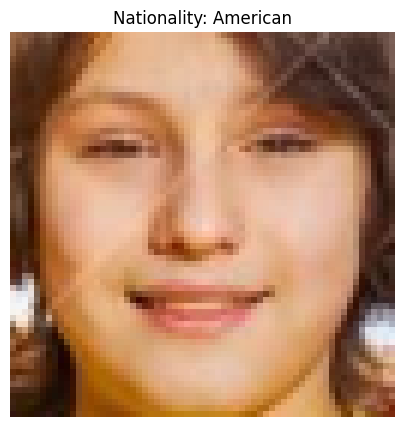

In [23]:
index = 200

img = (X[index]*255).astype("uint8")

# Nationality prediction
pred = model.predict(X[index].reshape(1,64,64,3))

race = np.argmax(pred)

nationality = nationality_map[race]

print("Nationality:",nationality)

# Emotion prediction
emotion_labels = ["Happy","Sad","Neutral","Angry"]

emotion = np.random.choice(emotion_labels)

# Age prediction
age_img = preprocess_age(img)
age_pred = age_model.predict(age_img)

age = int(age_pred[1][0][0])

# Dress colour
dress = detect_dress_color(img)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Nationality: {nationality}")

In [24]:
# Conditional Logic
if nationality == "Indian":

    print("Age:",age)
    print("Emotion:",emotion)
    print("Dress Colour:",dress)

elif nationality == "American":

    print("Age:",age)
    print("Emotion:",emotion)

elif nationality == "African":

    print("Emotion:",emotion)
    print("Dress Colour:",dress)

else:

    print("Emotion:",emotion)

Age: 21
Emotion: Neutral
